In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils import ResultLoader, plot_results, plot_results_split, plot_loss

# 设置绘图风格
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.titlesize': 20
})

loader = ResultLoader("../results")
algo = 'feddpc1'
loader.algo_patterns[algo] = lambda args: f"_{args['lamda_']}_{args['head_epochs']}_{args['body_epochs']}_{args['lr_head']}_{args['lr_body']}_{args['server_epochs']}_{args['server_lr']}_{args['margin_threshold']}_{args['lambda_p']}_{args['lambda_acl']}"

In [2]:
def load_and_plot_comparison(algo_name, param_name, param_values, common_args, x_lim=100, metric="acc"):
    """
    加载并绘制特定参数对比的通用函数
    """
    results = {}
    for val in param_values:
        args = common_args.copy()
        args[param_name] = val
        label = f"{param_name}={val}"
        data = loader.load(algo_name, **args, specific_run=0)
        if data:
            results[label] = data
        else:
            print(f"  [Warning] 未找到结果: {label}")

    if results:
        title = f"Comparison of {param_name} on {common_args['dataset']}"
        plot_results_split(results, x_lim, metric=metric, title=title, label_name=param_name)
    else:
        print("No results to plot.")

## 快速查看指定参数结果

在此单元格手动输入一组参数，直接加载并对比其表现。

Figure saved to figures/split_manual_check:_feddpc1.png

Summary of ACC:
--------------------------------------------------------------------------------
Param                |    Model Max | Model Last10 |    Proto Max | Proto Last10
--------------------------------------------------------------------------------
ACC                  |      85.8144 |      84.6203 |      85.8443 |      84.6562
--------------------------------------------------------------------------------


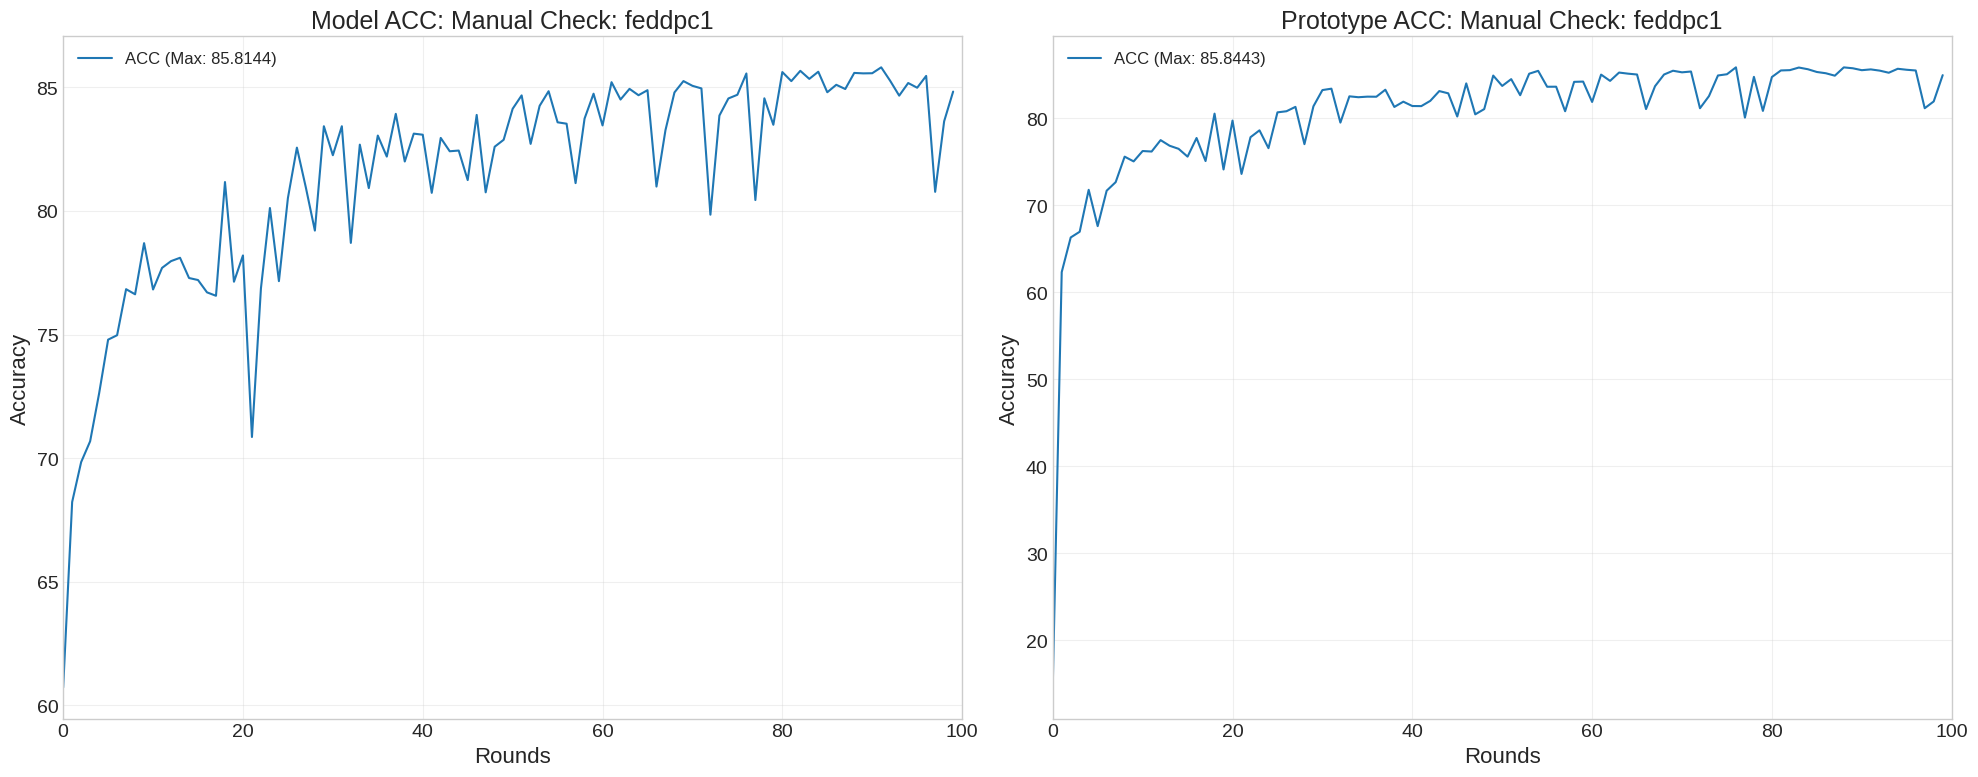

In [12]:
# ================== 指定观测参数 ==================
target_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "model": "cnn",
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 100.0,
    "lambda_p": 1.0,
    "lambda_acl": 0.1,
    "head_epochs": 10,
    "body_epochs": 1,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01,
    "margin_threshold": 100.0
}
# ================================================

data = loader.load(algo, **target_args, specific_run=0)
if data:
    results = {"ACC": data}
    plot_results_split(results, x_lim=100, metric="acc", title=f"Manual Check: {algo}", label_name="Param")
else:
    print("[Error] 未找到指定参数的结果，请检查路径。")

## 单元格 1: Lambda ($\lambda$) 对比

$\lambda$ 控制特征提取器与全局原型的对齐强度。

In [4]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "model": "cnn",
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "head_epochs": 10,
    "body_epochs": 2,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01,
    "margin_threshold": 10.0,
    "lambda_p": 1.0,
    "lambda_acl": 0.01
}

params = [0.1, 1.0, 10.0, 100.0, 1000.0]
load_and_plot_comparison(algo, "lamda_", params, common_args)

  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_0.1_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_0.1_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: lamda_=0.1
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_1.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_1.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: lamda_=1.0
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: lamda_=10.0
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_100.0_10_2_0.01_0.01_100_0.

## 单元格 2: Head Epochs 对比

本地分类头训练轮数。

In [5]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "model": "cnn",
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 10.0,
    "body_epochs": 1,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01,
    "margin_threshold": 10.0,
    "lambda_p": 1.0,
    "lambda_acl": 0.01
}

params = [1, 5, 10, 20, 50]
load_and_plot_comparison(algo, "head_epochs", params, common_args)

  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_1_1_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_1_1_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: head_epochs=1
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_5_1_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_5_1_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: head_epochs=5
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_1_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_1_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: head_epochs=10
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_20_1_0.01_0.0

## 单元格 3: Body Epochs 对比

本地特征提取器训练轮数。

In [6]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "model": "cnn",
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 10.0,
    "head_epochs": 10,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01,
    "margin_threshold": 10.0,
    "lambda_p": 1.0,
    "lambda_acl": 0.01
}

params = [1, 2, 5, 10]
load_and_plot_comparison(algo, "body_epochs", params, common_args)

  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_1_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_1_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: body_epochs=1
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: body_epochs=2
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_5_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_5_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: body_epochs=5
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_10_0.01

## 单元格 4: Server Epochs 对比

服务端 PLN 训练轮数。

In [7]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "model": "cnn",
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 10.0,
    "head_epochs": 10,
    "body_epochs": 2,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_lr": 0.01,
    "margin_threshold": 10.0,
    "lambda_p": 1.0,
    "lambda_acl": 0.01
}

params = [50, 100, 200, 500]
load_and_plot_comparison(algo, "server_epochs", params, common_args)

  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_50_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_50_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: server_epochs=50
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: server_epochs=100
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_200_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_200_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: server_epochs=200
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_1

## 单元格 5: Server Learning Rate 对比

服务端 PLN 学习率。

In [8]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "model": "cnn",
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 10.0,
    "head_epochs": 10,
    "body_epochs": 2,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "margin_threshold": 10.0,
    "lambda_p": 1.0,
    "lambda_acl": 0.01
}

params = [0.001, 0.01, 0.1]
load_and_plot_comparison(algo, "server_lr", params, common_args)

  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.001_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.001_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: server_lr=0.001
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: server_lr=0.01
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.1_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.1_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: server_lr=0.1
No results to plot.


## 单元格 6: Margin Threshold 对比

对比学习中的边界阈值。

In [9]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "model": "cnn",
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 10.0,
    "head_epochs": 10,
    "body_epochs": 2,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01,
    "lambda_p": 1.0,
    "lambda_acl": 0.01
}

params = [1.0, 5.0, 10.0, 20.0, 50.0]
load_and_plot_comparison(algo, "margin_threshold", params, common_args)

  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_1.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_1.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: margin_threshold=1.0
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_5.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_5.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: margin_threshold=5.0
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: margin_threshold=10.0
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.

## 单元格 7: Lambda P ($\lambda_p$) 对比

$\lambda_p$ 控制本地训练中原型匹配损失的权重。

In [10]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "model": "cnn",
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 10.0,
    "head_epochs": 10,
    "body_epochs": 2,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01,
    "margin_threshold": 10.0,
    "lambda_acl": 0.01
}

params = [0.01, 0.1, 1.0, 10.0]
load_and_plot_comparison(algo, "lambda_p", params, common_args)

  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_0.01_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_0.01_0.01_0.pt'
  [Warning] 未找到结果: lambda_p=0.01
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_0.1_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_0.1_0.01_0.pt'
  [Warning] 未找到结果: lambda_p=0.1
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: lambda_p=1.0
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_

## 单元格 8: Lambda ACL ($\lambda_{acl}$) 对比

$\lambda_{acl}$ 控制服务端 PLN 训练中对比损失的权重。

In [11]:
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "model": "cnn",
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "lamda_": 10.0,
    "head_epochs": 10,
    "body_epochs": 2,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "server_epochs": 100,
    "server_lr": 0.01,
    "margin_threshold": 10.0,
    "lambda_p": 1.0
}

params = [0.0001, 0.001, 0.01, 0.1, 1.0]
load_and_plot_comparison(algo, "lambda_acl", params, common_args)

  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.0001_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.0001_0.pt'
  [Warning] 未找到结果: lambda_acl=0.0001
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.001_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.001_0.pt'
  [Warning] 未找到结果: lambda_acl=0.001
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt: [Errno 2] No such file or directory: '../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_10.0_10_2_0.01_0.01_100_0.01_10.0_1.0_0.01_0.pt'
  [Warning] 未找到结果: lambda_acl=0.01
  [Error] Failed to load ../results/feddpc1/cifar10_dirichlet_10_0.1/1_64_0.01_